L. Parker and S. M. Christensen, *MathTensor: A System for Doing Tensor Analysis by Computer* (Addison-Wesley, 1994)

In [1]:
<< mTensor`

# Chapter 2. An Introduction to Tensors and Differential Forms

## 2.1 Tensors of Rank 1: Vectors

### 2.1.1 Covariant Vectors

Covariant vector: $v_a$

Coordinate transformation of components:
$$
  v'_a = \frac{\partial x^b}{\partial x'_a} v_b
$$

### 2.1.2 Contravariant Vectors

Contravariant vector: $v^a$

Coordinate transformation of components:
$$
  v'^a = \frac{\partial x'^a}{\partial x_b} v^b
$$

## 2.2 Tensors of Higher Rank

Rank-3 tensor: $t_a^{\ \ bc}$

Coordinate transformation of components:
$$
  t'^{bc}_a = \frac{\partial x^d}{\partial x'_a}
  \frac{\partial x'^b}{\partial x_e}
  \frac{\partial x'^c}{\partial x_f} t^{\ \ ef}_d
$$

## 2.3 Exterior Differential Forms

Differential: $dx^a$

Exterior or Wedge product: $dx^a \wedge dx^b = -dx^b \wedge dx^a$

For arbitrary forms $\alpha$ and $\beta$
$$
  \omega = \alpha \wedge \beta
$$

1-form: $\omega = \omega_a dx^a$ 

2-form: $\omega = \frac{1}{2!} \omega_{[ab]} dx^a \wedge dx^b$

3-form: $\omega = \frac{1}{3!} \omega_{[abc]} dx^a \wedge dx^b \wedge dx^c$

## 2.4 The Lie Derivative

Lie derivative of $t_a^{\ \ b}$ along the $v$-direction:
$$
  \mathcal{L}_v t_a^{\ \ b} = v^p \partial_p t_a^{\ \ b}
  + (\partial_a v^p) t_p^{\ \ b}
  - (\partial_p v^b) t_a^{\ \ p}
$$

## 2.5 Affine Connection, Covariant Derivative, Torsion

Covariant derivative:
\begin{gather*}
  \nabla_a v^b = \partial_a v^b + \Gamma_{ap}^{\ \ \ b} v^p \\
  \nabla_a v_b = \partial_a v_b - \Gamma_{ab}^{\ \ \ p} v_p \\
  \nabla_a t_b^{\ \ c} = \partial_a t_b^{\ \ c}
  - \Gamma_{ab}^{\ \ \ p} t_p^{\ \ c}
  + \Gamma_{ap}^{\ \ \ c} t_b^{\ \ p}
\end{gather*}

Torsion:
$$
  t_{ab}^{\ \ \ c} = \Gamma_{ab}^{\ \ \ c} - \Gamma_{ba}^{\ \ \ c}
$$

벡터 $v$와 텐서 $t$를 정의한다:

In [2]:
Tdefine[v, 1]; Tdefine[t, 2]

벡터 $v$ 방향으로 텐서 $t$의 Lie 도함수이다:

In [3]:
LD[v, t[ua, ub]]

LD[v, t[ua, ub]]

Lie 도함수를 공변 도함수로 바꾼다:
$$
  \mathcal{L}_v t^{ab} = v^c \nabla_c t^{ab}
  - (\nabla_c v^a) t^{cb} - (\nabla_c v^b) t^{ac}
$$

In [4]:
% // LDtoCD

-(CD[lc, v[ub]] t[ua, uc]) - CD[lc, v[ua]] t[uc, ub] + CD[lc, t[ua, ub]] v[uc]

공변 도함수를 보통 도함수로 바꾼다:

In [5]:
% // CDtoGamma

-(BD[lc, v[ub]] t[ua, uc]) - BD[lc, v[ua]] t[uc, ub] + BD[lc, t[ua, ub]] v[uc] + 
 
>   GammaCD[lc, ld, ub] t[ua, ud] v[uc] + GammaCD[lc, ld, ua] t[ud, ub] v[uc] - 
 
>   GammaCD[lc, ld, ub] t[ua, uc] v[ud] - GammaCD[lc, ld, ua] t[uc, ub] v[ud]

In [6]:
% // Tsimplify

-(BD[lc, v[ub]] t[ua, uc]) - BD[lc, v[ua]] t[uc, ub] + BD[lc, t[ua, ub]] v[uc]

유사한 방법으로 Lie 도함수를 보통 도함수로 바꾼다:
$$
  \mathcal{L}_v t_{ab} = v^c \partial_c t_{ab}
  + (\partial_a v^c) t_{cb} + (\partial_b v^c) t_{ac}
$$

In [7]:
LD[v, t[la, lb]]

LD[v, t[la, lb]]

In [8]:
% // LDtoCD // CDtoGamma // Tsimplify

BD[lb, v[uc]] t[la, lc] + BD[la, v[uc]] t[lc, lb] + BD[lc, t[la, lb]] v[uc]

$$
  \mathcal{L}_v t^a_{\ b} = v^c \partial_c t^a_{\ b}
  - (\partial_c v^a) t^c_{\ b} + (\partial_b v^c) t^a_{\ c}
$$

In [9]:
LD[v, t[ua, lb]]

LD[v, t[ua, lb]]

In [10]:
% // LDtoCD // CDtoGamma // Tsimplify

BD[lb, v[uc]] t[ua, lc] - BD[lc, v[ua]] t[uc, lb] + BD[lc, t[ua, lb]] v[uc]

## 2.6 The Metric Tensor

Line element:
$$
  ds^2 = g_{ab} dx^a dx^b
$$

### 2.6.1 Affine Connection and the Metric

In the torsion-free spacetime and in the coordinate basis, the covariantly constant condition of $g_{ab}$, $\nabla_a g_{bc} = 0$, gives the Christoffel symbols
$$
  \Gamma_{ab}^{\ \ \ c} = \frac{1}{2} g^{cd} (\partial_a g_{bd}
  + \partial_b g_{ad} - \partial_d g_{ab})
$$

### 2.6.2 Geodesics

$$
  v^a \equiv \frac{dx^a}{d\lambda}, \qquad v^a \nabla_a v^b = 0
$$

In [11]:
v[ua] CD[la, v[ub]]

CD[la, v[ub]] v[ua]

In [12]:
% // CDtoGamma

BD[la, v[ub]] v[ua] + GammaCD[la, lc, ub] v[ua] v[uc]

### 2.6.3 Lowering and Raising indices

$$
  v^a \equiv g^{ab} v_b, \qquad v_a \equiv g_{ab} v^b
$$

## 2.7 The Riemann Curvature Tensor

곡률 텐서의 정의:
$$
  (\nabla_a \nabla_b - \nabla_b \nabla_a + t_{ab}^{\ \ \ c}) v^d
  \equiv -R_{abc}^{\ \ \ \ \ d} v^c
$$

In [13]:
Tdefine[v, "a"]

In [14]:
CD[la, lb, v[ud]] - CD[lb, la, v[ud]]  (* torsion-free *)

CD[la, CD[lb, v[ud]]] - CD[lb, CD[la, v[ud]]]

In [15]:
% // CDtoGamma

BD[la, CD[lb, v[ud]]] - BD[lb, CD[la, v[ud]]] - CD[lc, v[ud]] GammaCD[la, lb, uc] + 
 
>   CD[lb, v[uc]] GammaCD[la, lc, ud] + CD[lc, v[ud]] GammaCD[lb, la, uc] - 
 
>   CD[la, v[uc]] GammaCD[lb, lc, ud]

In [16]:
% // CDtoGamma

BD[la, BD[lb, v[ud]]] - BD[lb, BD[la, v[ud]]] - BD[lc, v[ud]] GammaCD[la, lb, uc] + 
 
>   BD[lc, v[ud]] GammaCD[lb, la, uc] + BD[la, GammaCD[lb, lc, ud]] v[uc] - 
 
>   BD[lb, GammaCD[la, lc, ud]] v[uc] - GammaCD[la, le, uc] GammaCD[lb, lc, ud] v[ue] + 
 
>   GammaCD[la, lc, ud] GammaCD[lb, le, uc] v[ue] - 
 
>   GammaCD[la, lb, uc] GammaCD[lc, le, ud] v[ue] + 
 
>   GammaCD[lb, la, uc] GammaCD[lc, le, ud] v[ue]

In [17]:
% // Tsimplify

BD[la, GammaCD[lb, lc, ud]] v[uc] - BD[lb, GammaCD[la, lc, ud]] v[uc] - 
 
>   GammaCD[la, lc, ue] GammaCD[lb, le, ud] v[uc] + 
 
>   GammaCD[la, lc, ud] GammaCD[lb, le, uc] v[ue]

In [18]:
-RiemannCD[la, lb, lc, ud] v[uc]

-(RiemannCD[la, lb, lc, ud] v[uc])

In [19]:
% // RiemannToGamma

BD[la, GammaCD[lb, lc, ud]] v[uc] - BD[lb, GammaCD[la, lc, ud]] v[uc] + 
 
>   GammaCD[la, le, ud] GammaCD[lb, lc, ue] v[uc] - 
 
>   GammaCD[la, lc, ue] GammaCD[lb, le, ud] v[uc]

따라서
$$
  R_{abc}^{\ \ \ \ \ d} = -\left[ \partial_a \Gamma_{bc}^{\ \ \ d}
  + \Gamma_{ap}^{\ \ \ d} \Gamma_{bc}^{\ \ \ p}
  - (a \leftrightarrow b) \right]
$$

곡률 텐서의 대칭:
\begin{align*}
  R_{abcd} & = R_{[ab][cd]} \\
  & = R_{cdab} \qquad \textrm{for torsion-free}
\end{align*}

In [20]:
GetSymmetry[RiemannCD] // GStoString

-bacd-abdc+cdab

In [21]:
% // AllPermutations

+abcd-abdc-bacd+badc+cdab-cdba-dcab+dcba

Bianchi 항등식:
\begin{gather*}
  R_{[abc]}^{\ \ \ \ \ \ \ \ d} = -\left(
  \nabla_{[a} t_{b]c}^{\ \ \ \ d}
  - t_{[ab}^{\ \ \ \ p} t_{c]p}^{\ \ \ \ \ d} \right) \\
  \nabla_{[a} R_{bc]d}^{\ \ \ \ \ \ \ e}
  = t_{[ab}^{\ \ \ \ p} R_{c]pd}^{\ \ \ \ \ \ \ e}
\end{gather*}

In [22]:
exprBianchi = 
 CD[la, RiemannCD[lb, lc, ld, ue]] + 
  CD[lb, RiemannCD[lc, la, ld, ue]] + 
  CD[lc, RiemannCD[la, lb, ld, ue]]

CD[la, RiemannCD[lb, lc, ld, ue]] + CD[lb, RiemannCD[lc, la, ld, ue]] + 
 
>   CD[lc, RiemannCD[la, lb, ld, ue]]

BD[la, RiemannCD[lb, lc, ld, ue]] + BD[lb, RiemannCD[lc, la, ld, ue]] + 
 
>   BD[lc, RiemannCD[la, lb, ld, ue]] + GammaCD[lc, lf, ue] RiemannCD[la, lb, ld, uf] - 
 
>   GammaCD[lc, ld, uf] RiemannCD[la, lb, lf, ue] - 
 
>   GammaCD[lc, lb, uf] RiemannCD[la, lf, ld, ue] + 
 
>   GammaCD[la, lf, ue] RiemannCD[lb, lc, ld, uf] - 
 
>   GammaCD[la, ld, uf] RiemannCD[lb, lc, lf, ue] - 
 
>   GammaCD[la, lc, uf] RiemannCD[lb, lf, ld, ue] + 
 
>   GammaCD[lb, lf, ue] RiemannCD[lc, la, ld, uf] - 
 
>   GammaCD[lb, ld, uf] RiemannCD[lc, la, lf, ue] - 
 
>   GammaCD[lb, la, uf] RiemannCD[lc, lf, ld, ue] - 
 
>   GammaCD[lb, lc, uf] RiemannCD[lf, la, ld, ue] - 
 
>   GammaCD[lc, la, uf] RiemannCD[lf, lb, ld, ue] - 
 
>   GammaCD[la, lb, uf] RiemannCD[lf, lc, ld, ue]
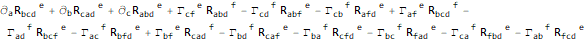

In [23]:
% // CDtoGamma

-BD[la, BD[lb, GammaCD[lc, ld, ue]]] + BD[la, BD[lc, GammaCD[lb, ld, ue]]] + 
 
>   BD[lb, BD[la, GammaCD[lc, ld, ue]]] - BD[lb, BD[lc, GammaCD[la, ld, ue]]] - 
 
>   BD[lc, BD[la, GammaCD[lb, ld, ue]]] + BD[lc, BD[lb, GammaCD[la, ld, ue]]] - 
 
>   BD[lc, GammaCD[lf, ld, ue]] GammaCD[la, lb, uf] + 
 
>   BD[lf, GammaCD[lc, ld, ue]] GammaCD[la, lb, uf] + 
 
>   BD[lb, GammaCD[lf, ld, ue]] GammaCD[la, lc, uf] - 
 
>   BD[lf, GammaCD[lb, ld, ue]] GammaCD[la, lc, uf] + 
 
>   BD[lc, GammaCD[lf, ld, ue]] GammaCD[lb, la, uf] - 
 
>   BD[lf, GammaCD[lc, ld, ue]] GammaCD[lb, la, uf] - 
 
>   BD[la, GammaCD[lf, ld, ue]] GammaCD[lb, lc, uf] + 
 
>   BD[lf, GammaCD[la, ld, ue]] GammaCD[lb, lc, uf] - 
 
>   BD[lb, GammaCD[lf, ld, ue]] GammaCD[lc, la, uf] + 
 
>   BD[lf, GammaCD[lb, ld, ue]] GammaCD[lc, la, uf] + 
 
>   BD[la, GammaCD[lf, ld, ue]] GammaCD[lc, lb, uf] - 
 
>   BD[lf, GammaCD[la, ld, ue]] GammaCD[lc, lb, uf] + 
 
>   GammaCD[la, lg, ue] GammaCD[lb, lf, ug] GammaCD[lc, ld, uf] - 
 
>   GammaCD[la, lf, ug] GammaCD[lb, lg, ue] GammaCD[lc, ld, uf] + 
 
>   GammaCD[la, lg, uf] GammaCD[lb, lf, ue] GammaCD[lc, ld, ug] - 
 
>   GammaCD[la, lf, ue] GammaCD[lb, lg, uf] GammaCD[lc, ld, ug] - 
 
>   GammaCD[la, lg, uf] GammaCD[lb, ld, ug] GammaCD[lc, lf, ue] + 
 
>   GammaCD[la, ld, ug] GammaCD[lb, lg, uf] GammaCD[lc, lf, ue] - 
 
>   GammaCD[la, lg, ue] GammaCD[lb, ld, uf] GammaCD[lc, lf, ug] + 
 
>   GammaCD[la, ld, uf] GammaCD[lb, lg, ue] GammaCD[lc, lf, ug] + 
 
>   GammaCD[la, lf, ug] GammaCD[lb, ld, uf] GammaCD[lc, lg, ue] - 
 
>   GammaCD[la, ld, uf] GammaCD[lb, lf, ug] GammaCD[lc, lg, ue] + 
 
>   GammaCD[la, lf, ue] GammaCD[lb, ld, ug] GammaCD[lc, lg, uf] - 
 
>   GammaCD[la, ld, ug] GammaCD[lb, lf, ue] GammaCD[lc, lg, uf] - 
 
>   GammaCD[la, lg, ue] GammaCD[lb, lc, uf] GammaCD[lf, ld, ug] + 
 
>   GammaCD[la, lc, uf] GammaCD[lb, lg, ue] GammaCD[lf, ld, ug] - 
 
>   GammaCD[lb, lg, ue] GammaCD[lc, la, uf] GammaCD[lf, ld, ug] + 
 
>   GammaCD[la, lg, ue] GammaCD[lc, lb, uf] GammaCD[lf, ld, ug] - 
 
>   GammaCD[la, lb, uf] GammaCD[lc, lg, ue] GammaCD[lf, ld, ug] + 
 
>   GammaCD[lb, la, uf] GammaCD[lc, lg, ue] GammaCD[lf, ld, ug] + 
 
>   GammaCD[la, ld, ug] GammaCD[lb, lc, uf] GammaCD[lf, lg, ue] - 
 
>   GammaCD[la, lc, uf] GammaCD[lb, ld, ug] GammaCD[lf, lg, ue] + 
 
>   GammaCD[lb, ld, ug] GammaCD[lc, la, uf] GammaCD[lf, lg, ue] - 
 
>   GammaCD[la, ld, ug] GammaCD[lc, lb, uf] GammaCD[lf, lg, ue] + 
 
>   GammaCD[la, lb, uf] GammaCD[lc, ld, ug] GammaCD[lf, lg, ue] - 
 
>   GammaCD[lb, la, uf] GammaCD[lc, ld, ug] GammaCD[lf, lg, ue]
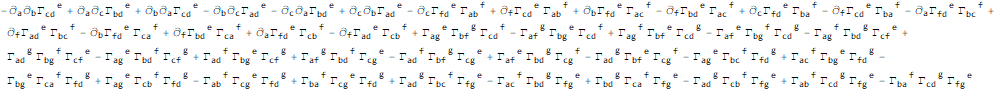

In [24]:
% // RiemannToGamma  (* torsion-free *)

In [25]:
% // Tsimplify

0

따라서 토션이 없는 시공간에서 비앙키 항등식은 $\nabla_{[a} R_{bc]d}^{\ \ \ \ \ \ \ e} = 0$이다.

### 2.7.1 The Ricci, Einstein, and Weyl Tensors

리치 텐서, 스칼라 곡률, 아인슈타인 텐서:
$$
  R_{ab} \equiv R_{apb}^{\ \ \ \ \ p}, \qquad R \equiv R_p^{\ p},
  \qquad G_{ab} \equiv R_{ab} - \frac{1}{2} g_{ab} R
$$

Bianchi 항등식과 아인슈타인 방정식:
$$
  \nabla^a G_{ab} = 0, \qquad
  G_{ab} = 8\pi G T_{ab}
$$

Weyl 텐서:
$$
  C_{abcd} = R_{abcd}
  - \frac{1}{n-2} \left[g_{ac} R_{bd} - g_{ad} R_{bc}
  - (a \leftrightarrow b) \right]
  + \frac{1}{(n-1)(n-2)} (g_{ac} g_{bd} - g_{ad} g_{bc}) R
$$

공변 도함수의 교환 공식:
$$
  (\nabla_a \nabla_b - \nabla_b \nabla_a
  + t_{ab}^{\ \ \ p} \nabla_p) s_{cd}^{\ \ \ e}
  = R_{abc}^{\ \ \ \ \ p} s_{pd}^{\ \ \ e}
  + R_{abd}^{\ \ \ \ \ p} s_{cp}^{\ \ \ e}
  - R_{abp}^{\ \ \ \ \ e} s_{cd}^{\ \ \ p}
$$

In [26]:
Tdefine[s, 3]

In [27]:
CD[la, lb, s[lc, ld, ue]]

CD[la, CD[lb, s[lc, ld, ue]]]

In [28]:
CommuteCD[{la, lb}, %]

CD[lb, CD[la, s[lc, ld, ue]]] - RiemannCD[la, lb, lf, ue] s[lc, ld, uf] + 
 
>   RiemannCD[la, lb, ld, uf] s[lc, lf, ue] + RiemannCD[la, lb, lc, uf] s[lf, ld, ue]